# Part 2: Denoising Autoencoder

In [1]:
# Execute this code block to install dependencies when running on colab
try:
    import torch
except:
    from os.path import exists
    from wheel.pep425tags import get_abbr_impl, get_impl_ver, get_abi_tag
    platform = '{}{}-{}'.format(get_abbr_impl(), get_impl_ver(), get_abi_tag())
    cuda_output = !ldconfig -p|grep cudart.so|sed -e 's/.*\.\([0-9]*\)\.\([0-9]*\)$/cu\1\2/'
    accelerator = cuda_output[0] if exists('/dev/nvidia0') else 'cpu'

    !pip install -q http://download.pytorch.org/whl/{accelerator}/torch-1.0.0-{platform}-linux_x86_64.whl torchvision

### Extend the Autoencoder you implemented in Part 1 to a Denoising Autoencoder

Recall from the lecture, a denoising autoencoder's architecture is very similar to a standard autoencoder. The difference is the input to the autoencoder has noise added to it. However, when computing the loss function, make sure the original (non-noisy) version is used for backpropagation.

Again, let's start by loading the Fashion-MNIST dataset and transforming it to a flattened tensor.

In [2]:
%matplotlib inline

import torchvision
import torchvision.transforms as transforms

import numpy as np

batch_size = 256
image_dim = 784  # [flattened]

# dataset construction
transform = transforms.Compose([
    transforms.ToTensor(), # convert to tensor
    transforms.Lambda(lambda x: x.view(image_dim)) # flatten into vector
    ])

train_set = torchvision.datasets.FashionMNIST(
    root='./data/FashionMNIST'
    ,train=True
    ,download=True
    ,transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 173kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.84MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.7MB/s]


## Build a Denoising Autoencoder

Now, define the Encoder and Decoder classes for your denoising autoencoder, called DN_Encoder, DN_Decoder, respectively. You can define these architectures how you like; some suggested architectures are given as comments in the classes below.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from tqdm.autonotebook import tqdm
from itertools import chain


class DN_Encoder(nn.Module):
    '''
    Denoising encoder with a single input, hidden and output layer
    '''
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(DN_Encoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


class DN_Decoder(nn.Module):
    '''
    Denoising decoder: single dense hidden layer followed by
    output layer with a sigmoid to squish values
    '''
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(DN_Decoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))  # Sigmoid for output
        return x

## Learning your Denoising Autoencoder

Start from the training procedure used in Part 1 for the autoencoder and extend this to get your denoising autoencoder working. Again, include images of both the data with added noise as well as the reconstructed images in the submitted notebook. Regarding the noise to add to your images, add Gaussian noise with a mean of 0 and a standard deviation of 1.

Epoch 1/10:   0%|          | 0/235 [00:00<?, ?it/s]

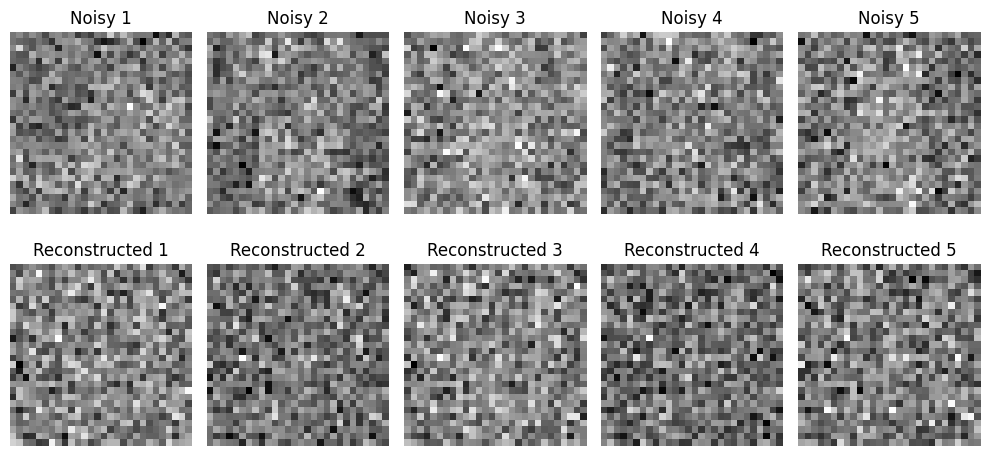

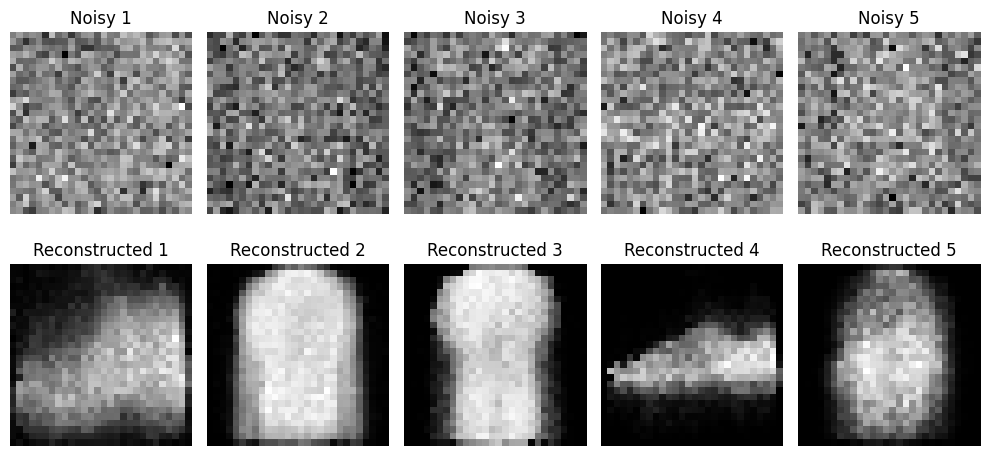

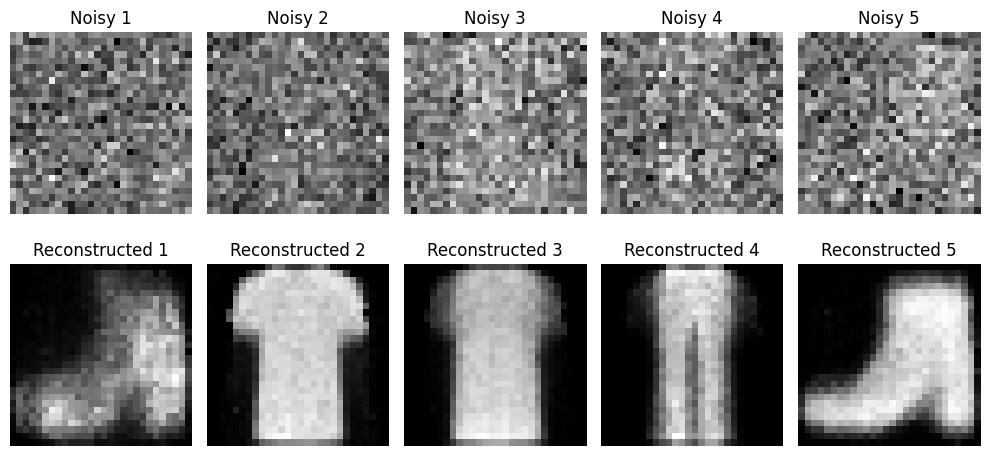

Epoch 2/10:   0%|          | 0/235 [00:00<?, ?it/s]

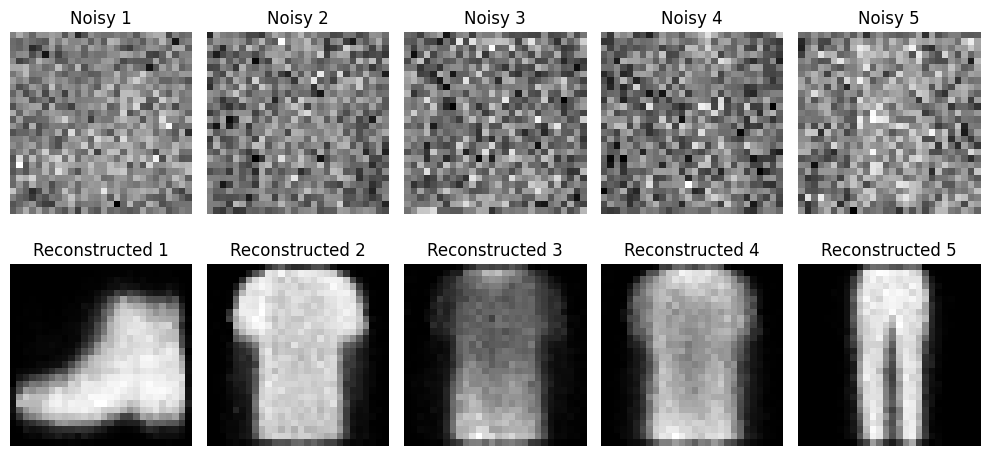

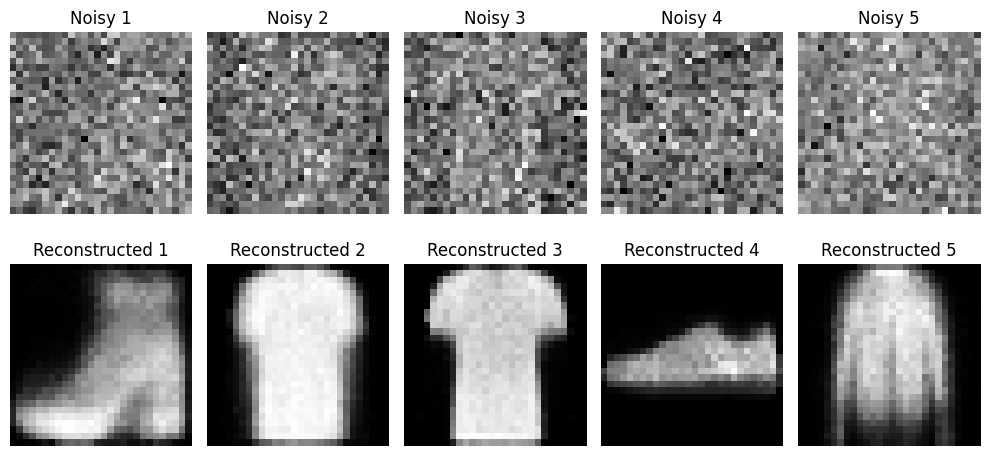

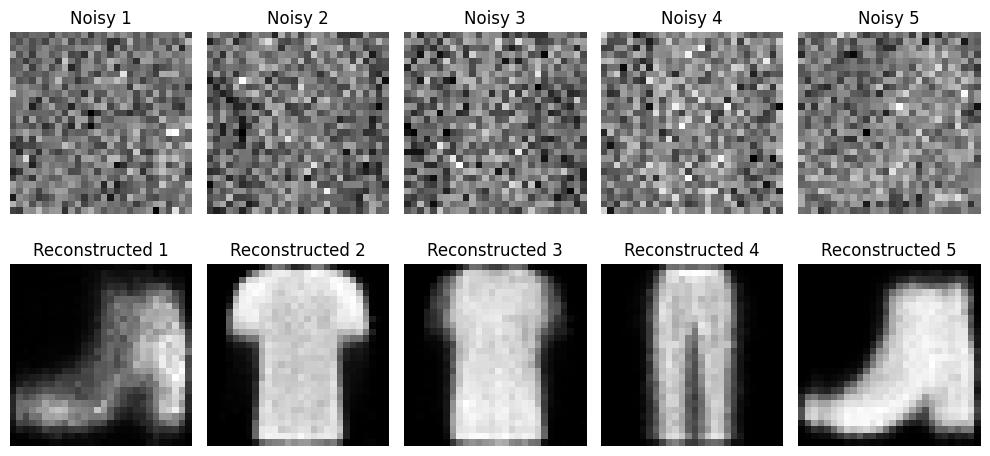

Epoch 3/10:   0%|          | 0/235 [00:00<?, ?it/s]

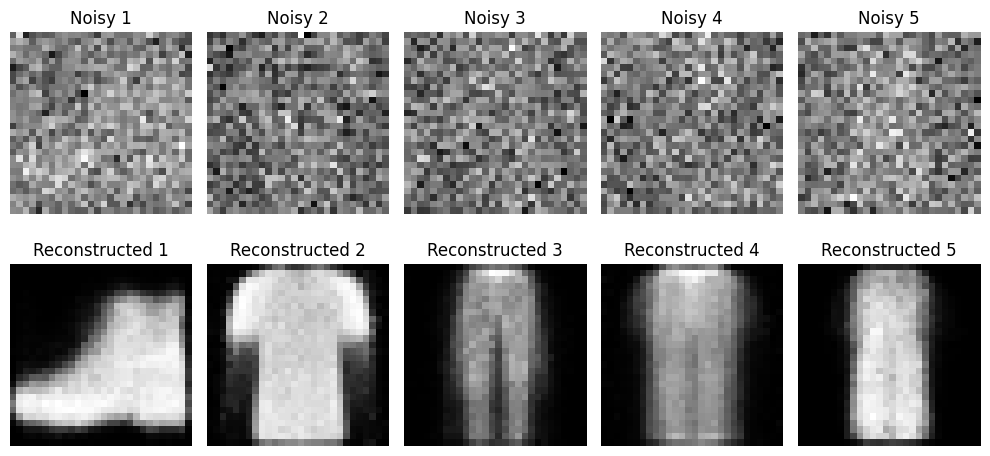

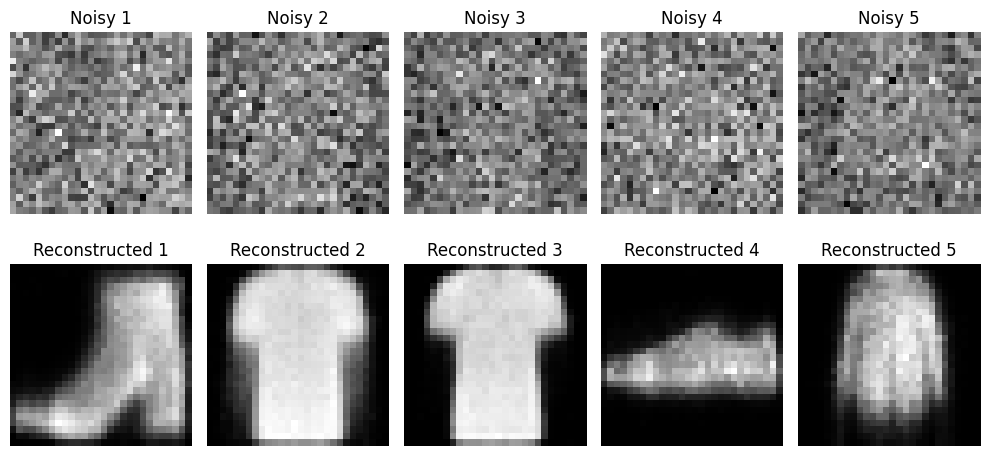

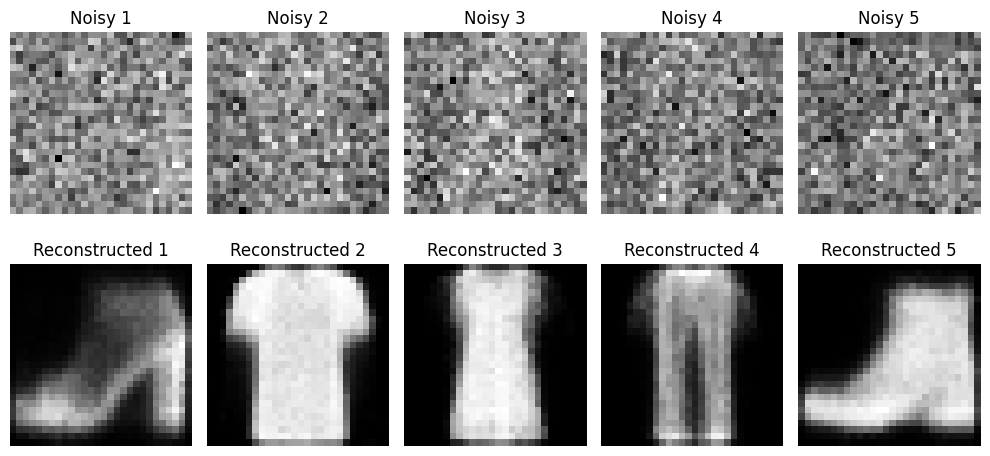

Epoch 4/10:   0%|          | 0/235 [00:00<?, ?it/s]

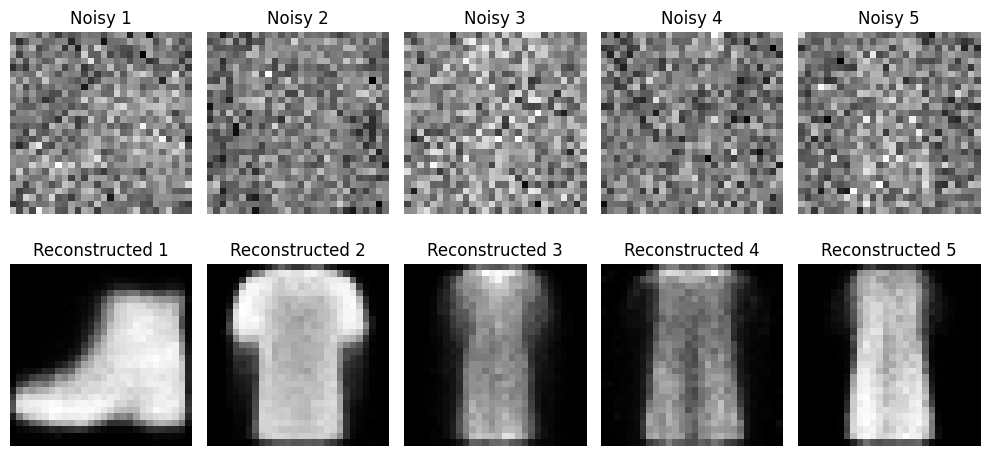

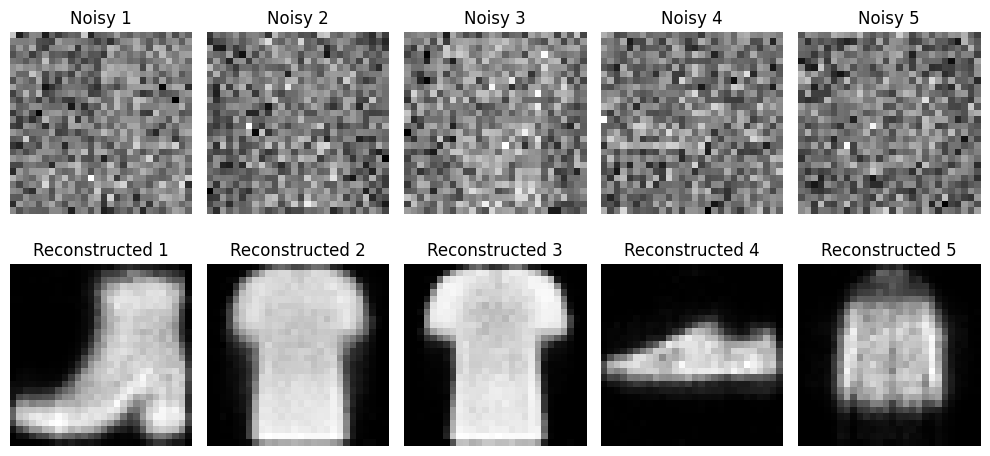

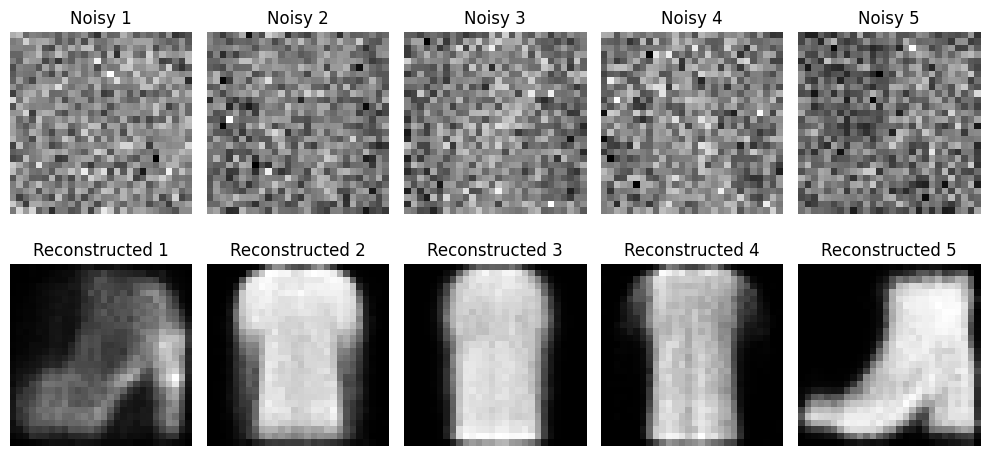

Epoch 5/10:   0%|          | 0/235 [00:00<?, ?it/s]

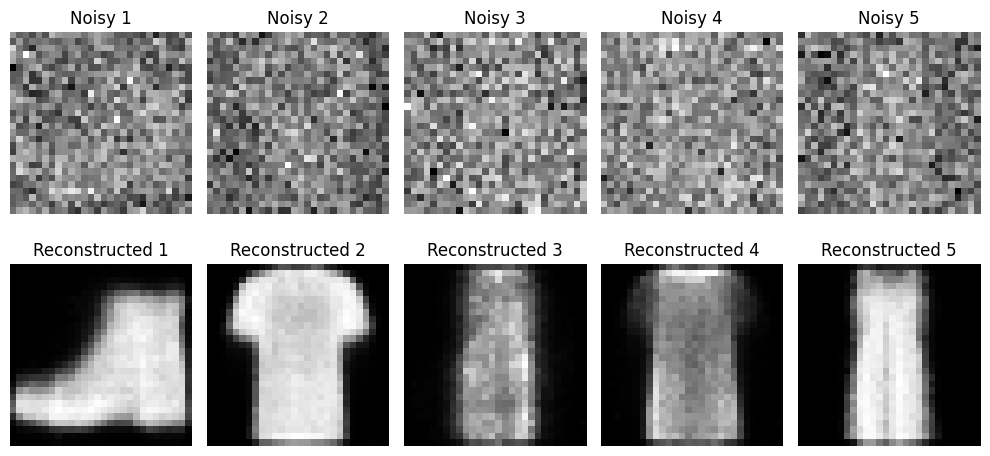

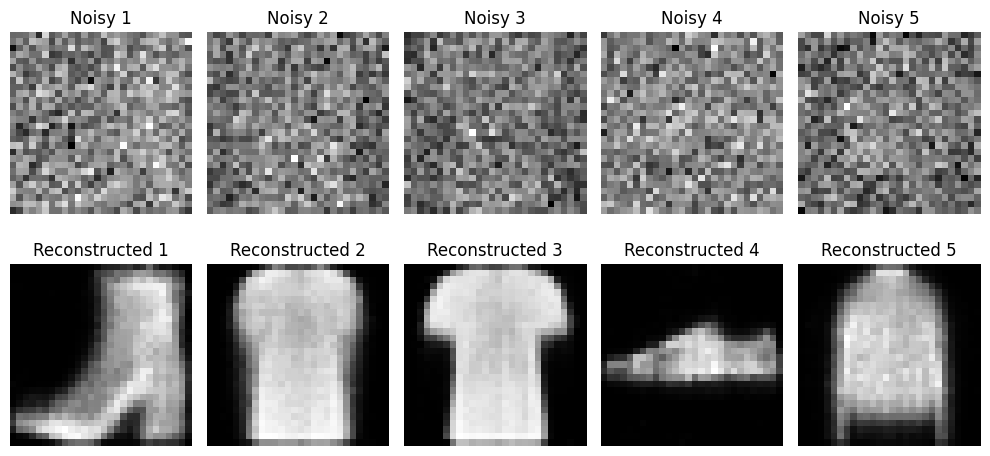

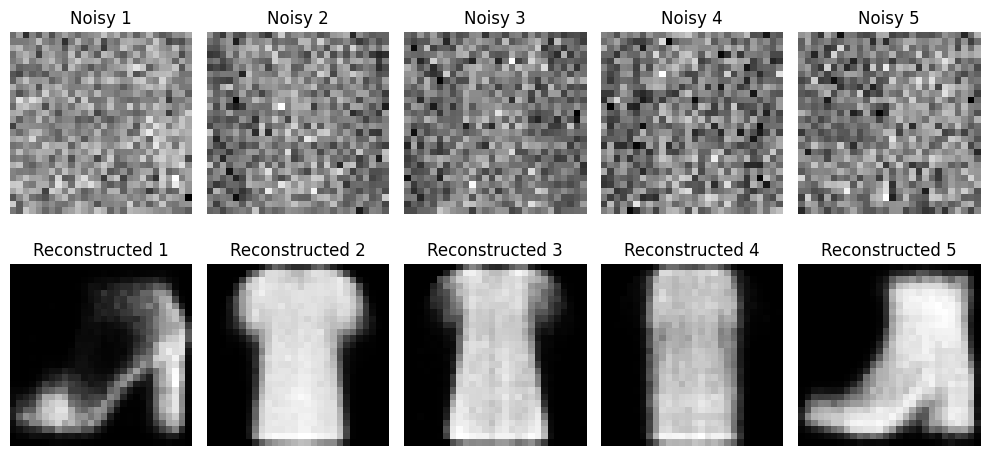

Epoch 6/10:   0%|          | 0/235 [00:00<?, ?it/s]

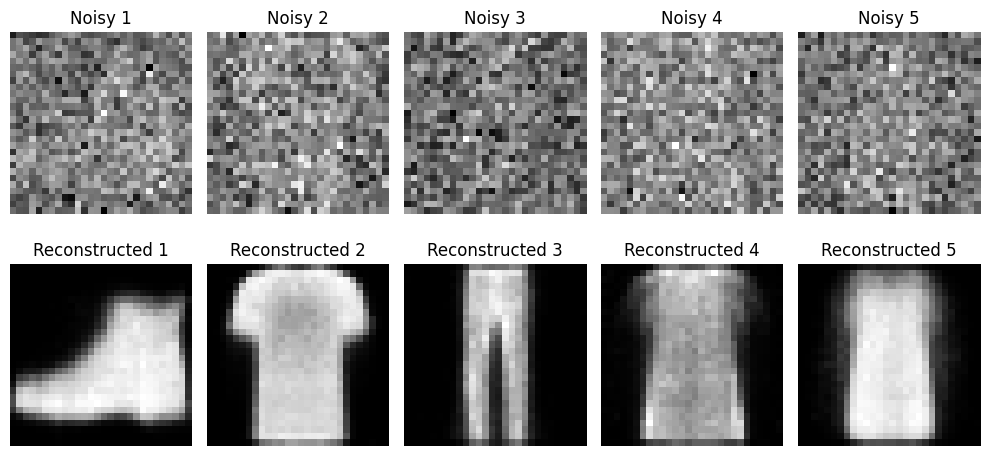

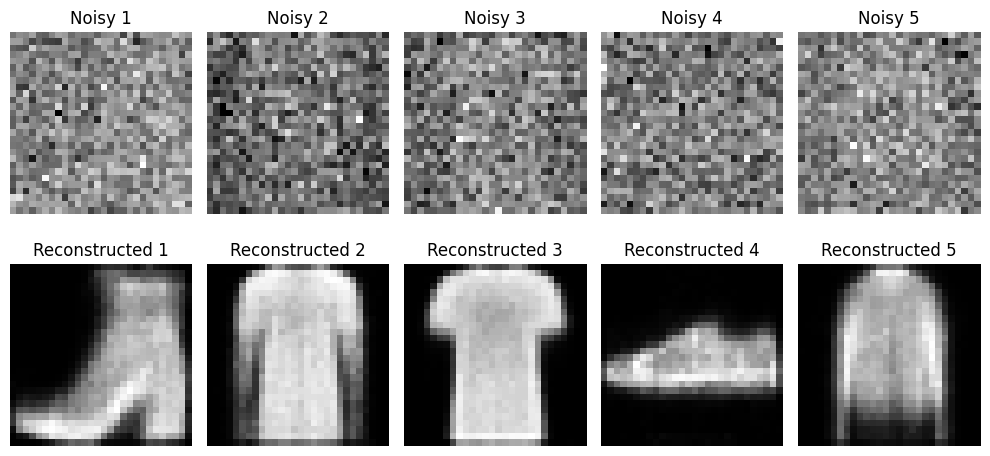

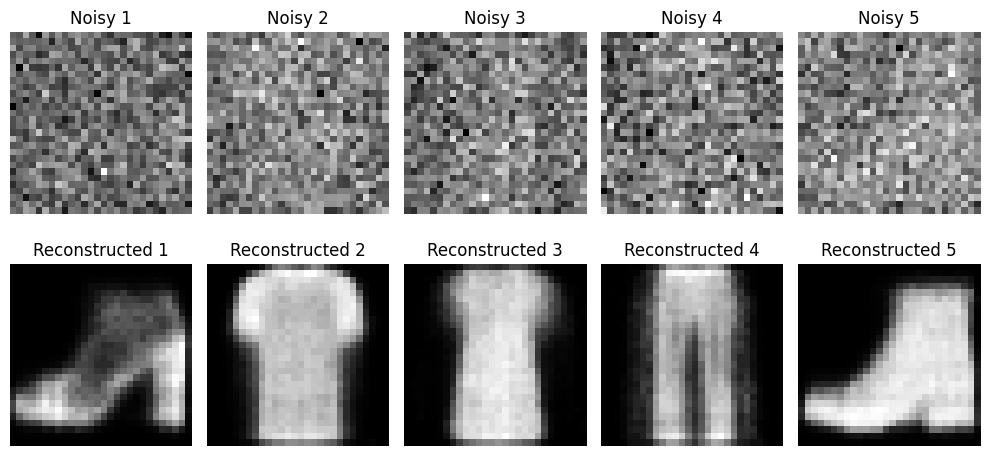

Epoch 7/10:   0%|          | 0/235 [00:00<?, ?it/s]

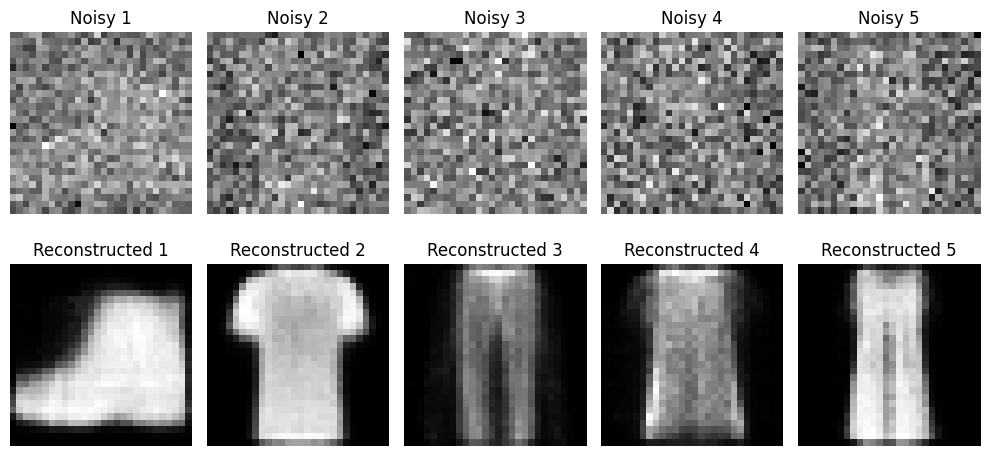

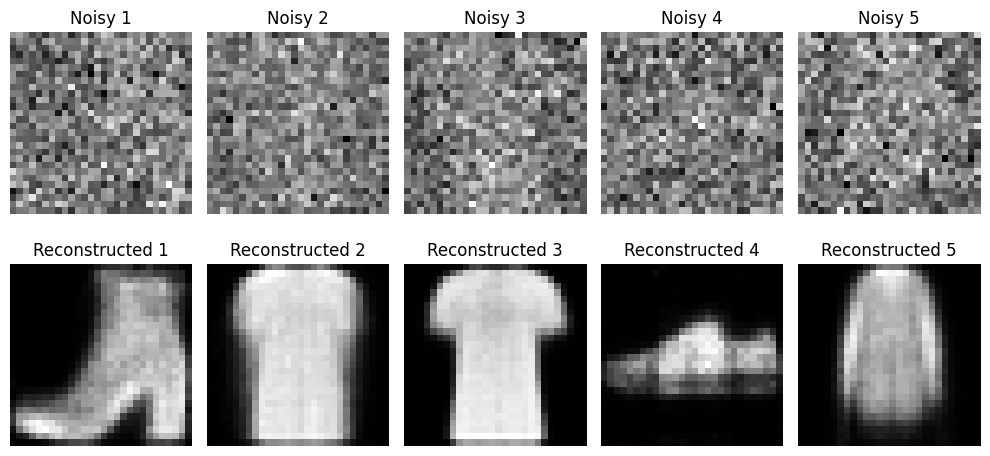

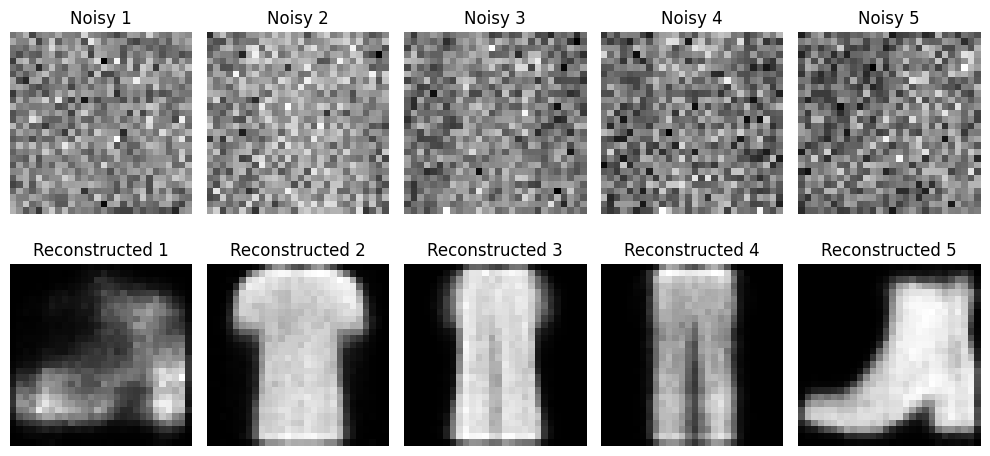

Epoch 8/10:   0%|          | 0/235 [00:00<?, ?it/s]

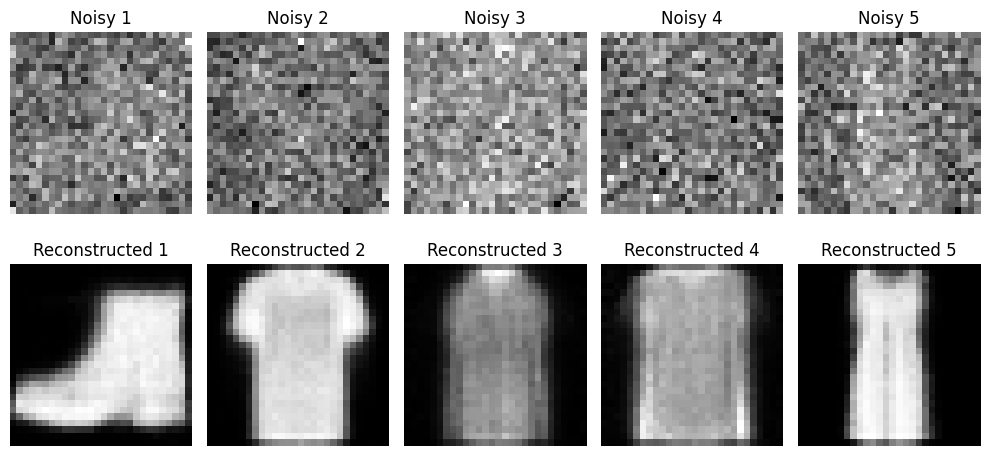

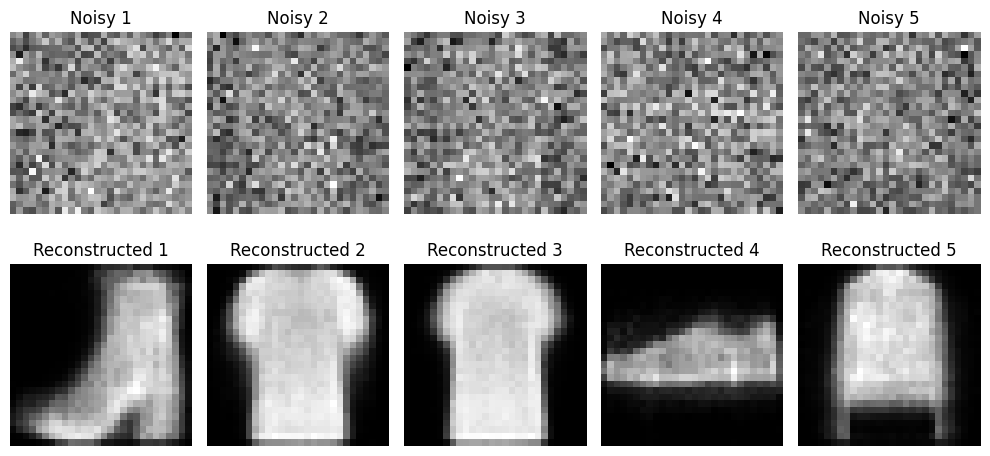

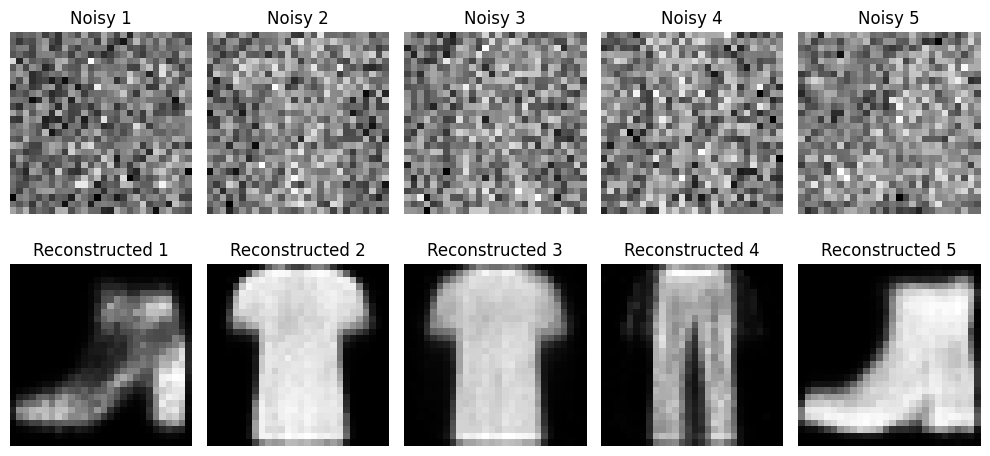

Epoch 9/10:   0%|          | 0/235 [00:00<?, ?it/s]

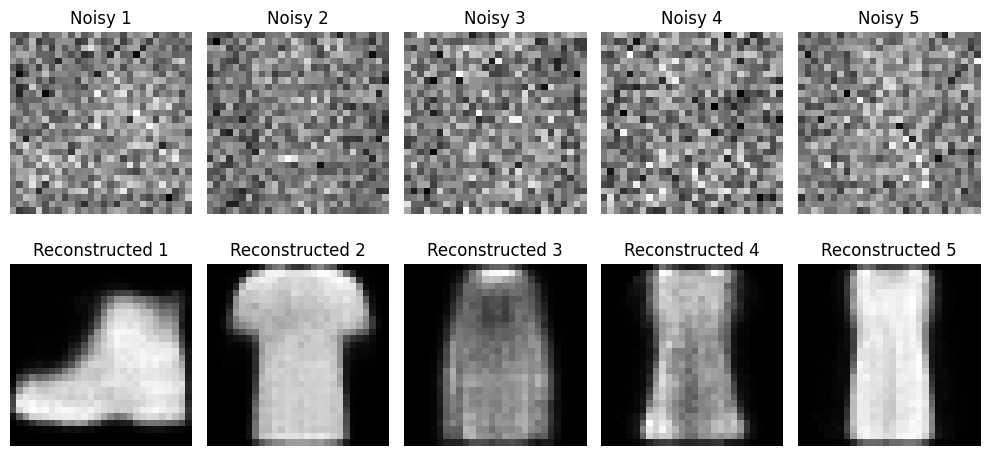

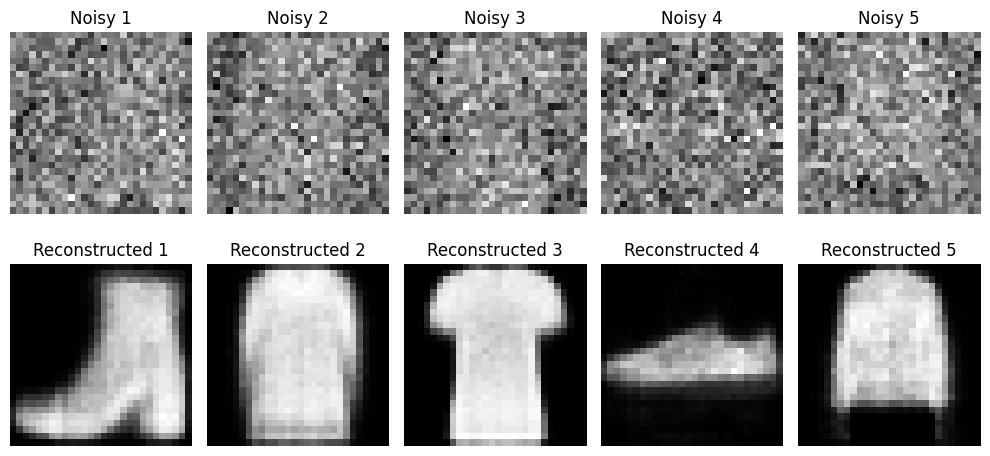

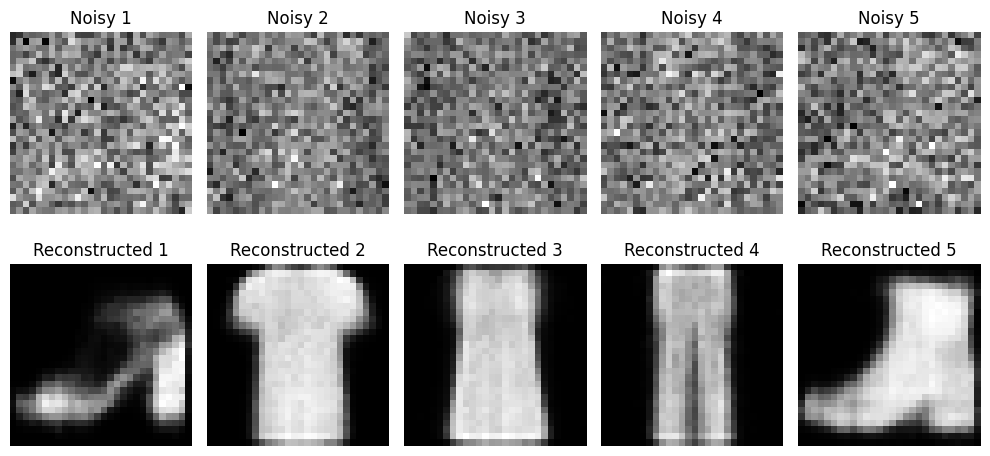

Epoch 10/10:   0%|          | 0/235 [00:00<?, ?it/s]

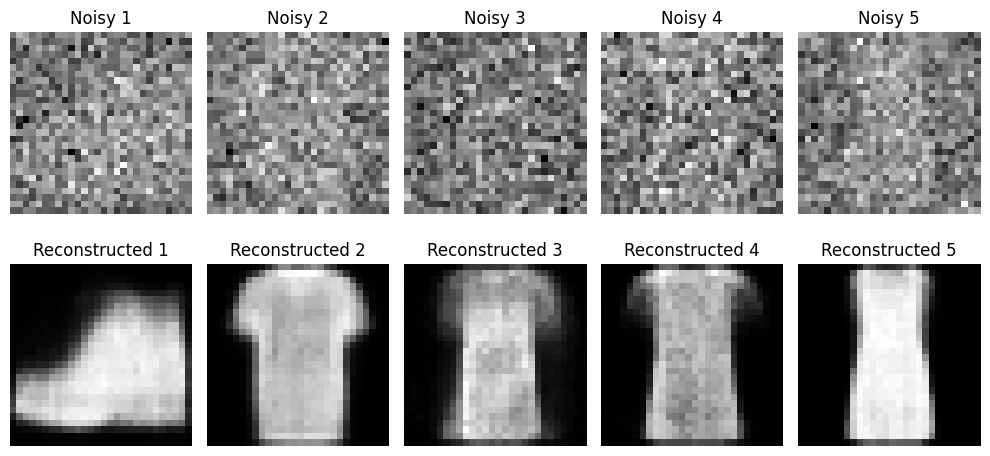

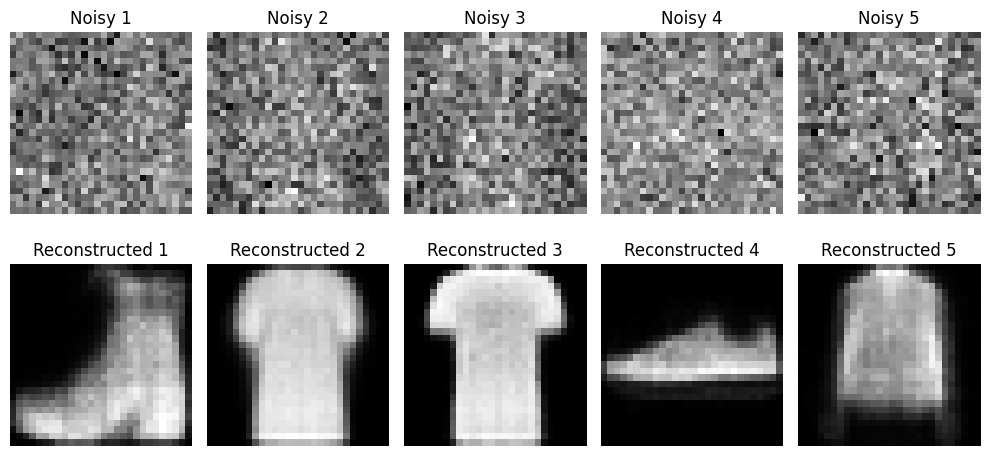

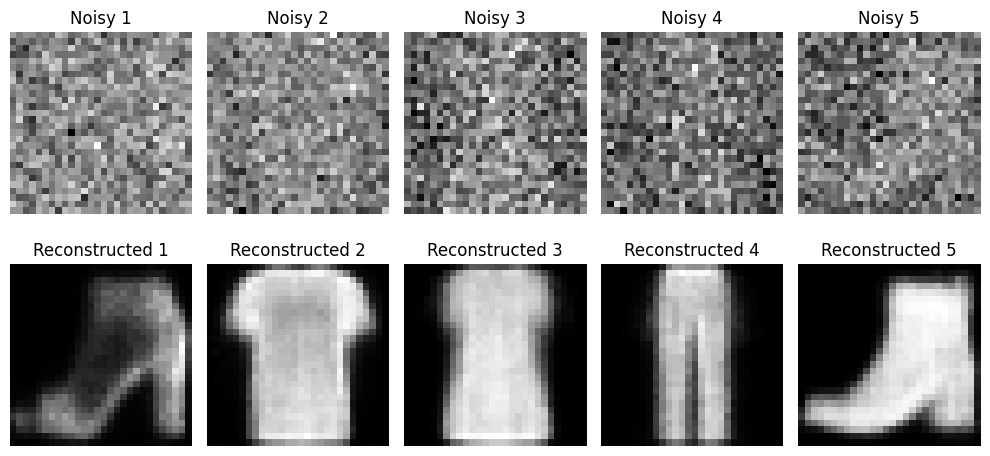

In [5]:
import matplotlib.pyplot as plt

# Define the denoising autoencoder
input_dim = image_dim  # 784 for flattened images
hidden_dim = 128  # Example hidden dimension
output_dim = input_dim  # Same as input for reconstruction

encoder = DN_Encoder(input_dim, hidden_dim, output_dim)
decoder = DN_Decoder(output_dim, hidden_dim, input_dim)

# Define the optimizer and loss function
optimizer = optim.Adam(chain(encoder.parameters(), decoder.parameters()))
criterion = nn.MSELoss()

# Training loop
epochs = 10  # Example number of epochs

for epoch in range(epochs):
    for batch_idx, (data, _) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}')):
        # Add Gaussian noise to the input data
        noisy_data = data + torch.randn_like(data)

        # Forward pass
        encoded = encoder(noisy_data)
        decoded = decoder(encoded)

        # Calculate loss using the original (non-noisy) data
        loss = criterion(decoded, data)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print progress (optional)
        if batch_idx % 100 == 0:
            # ... (print progress remains the same) ...

            # Display noisy and reconstructed images
            # Get some images from the batch
            num_images_to_display = 5
            noisy_images = noisy_data[:num_images_to_display].reshape(-1, 28, 28)
            reconstructed_images = decoded[:num_images_to_display].reshape(-1, 28, 28)

            # Create a figure and axes
            fig, axes = plt.subplots(nrows=2, ncols=num_images_to_display, figsize=(10, 5))

            # Display noisy images
            for i in range(num_images_to_display):
                axes[0, i].imshow(noisy_images[i], cmap='gray')
                axes[0, i].set_title(f'Noisy {i + 1}')
                axes[0, i].axis('off')

            # Display reconstructed images
            for i in range(num_images_to_display):
                axes[1, i].imshow(reconstructed_images[i].detach().numpy(), cmap='gray')  # Detach from computation graph
                axes[1, i].set_title(f'Reconstructed {i + 1}')
                axes[1, i].axis('off')

            plt.tight_layout()
            plt.show()